<h1>Train — ResNet-18 (baseline)</h1>

Trains and evaluates the ResNet-18 baseline classifier, then saves its results (`results_resnet18.pkl`) and weights (`{COMPONENT}_resnet18_cnn.pt`) to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1814 | Val: 441 | Test: 252


## Define the model (Transfer Learning with ResNet-18)

In [2]:
model_resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, num_classes)  # no hidden layers — this one predates the tuning sweep

model_resnet18 = model_resnet18.to(device)

# ---------------------------------------------------------
# Loss and optimizer, with class weights for the imbalanced classes
# ---------------------------------------------------------
class_weights = make_class_weights(train_ds)
print("Applying class weights to loss function:")
for name, w in zip(class_names, class_weights.cpu().numpy()):
    print(f"  {name:<15s}: {w:.3f}")

criterion_resnet18 = nn.CrossEntropyLoss(weight=class_weights)
optimizer_resnet18 = optim.Adam(model_resnet18.parameters(), lr=5e-4, weight_decay=WEIGHT_DECAY)

# mode='min' because we want to minimize loss; factor=0.5 halves the LR when
# triggered; patience=3 waits 3 epochs with no improvement before reducing it
scheduler_resnet18 = ReduceLROnPlateau(optimizer_resnet18, mode='min', factor=0.5, patience=3)

Applying class weights to loss function:
  Dysfunctional  : 1.501
  Empty          : 1.627
  Functional     : 0.448
  Scum           : 0.425


## Train, then plot training curves

[ResNet-18] Epoch   1/100 | LR: 5.00e-04 | train loss 0.7503 acc 0.676 | val loss 0.5719 acc 0.766 *


[ResNet-18] Epoch   2/100 | LR: 5.00e-04 | train loss 0.4395 acc 0.805 | val loss 0.4838 acc 0.807 *


[ResNet-18] Epoch   3/100 | LR: 5.00e-04 | train loss 0.3518 acc 0.839 | val loss 0.5085 acc 0.812


[ResNet-18] Epoch   4/100 | LR: 5.00e-04 | train loss 0.2726 acc 0.878 | val loss 0.5581 acc 0.785


[ResNet-18] Epoch   5/100 | LR: 5.00e-04 | train loss 0.2170 acc 0.904 | val loss 0.4729 acc 0.839 *


...

[ResNet-18] Epoch  19/100 | LR: 1.25e-04 | train loss 0.0021 acc 1.000 | val loss 0.4535 acc 0.898


[ResNet-18] Epoch  20/100 | LR: 1.25e-04 | train loss 0.0028 acc 0.999 | val loss 0.4456 acc 0.898


[ResNet-18] Epoch  21/100 | LR: 6.25e-05 | train loss 0.0032 acc 0.999 | val loss 0.4846 acc 0.887


[ResNet-18] Epoch  22/100 | LR: 6.25e-05 | train loss 0.0015 acc 1.000 | val loss 0.4705 acc 0.898


[ResNet-18] Epoch  23/100 | LR: 6.25e-05 | train loss 0.0023 acc 1.000 | val loss 0.4731 acc 0.896

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 23.

[ResNet-18] Restored best checkpoint (val loss = 0.4067)


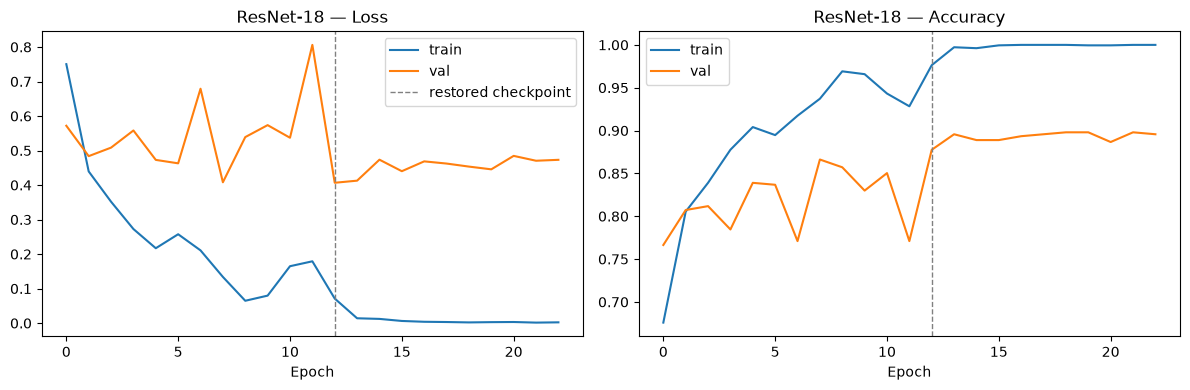

In [3]:
history_resnet18 = train_model(
    model_resnet18, train_loader, val_loader, optimizer_resnet18, scheduler_resnet18,
    criterion_resnet18, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18",
)
plot_training_curves(history_resnet18, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.679


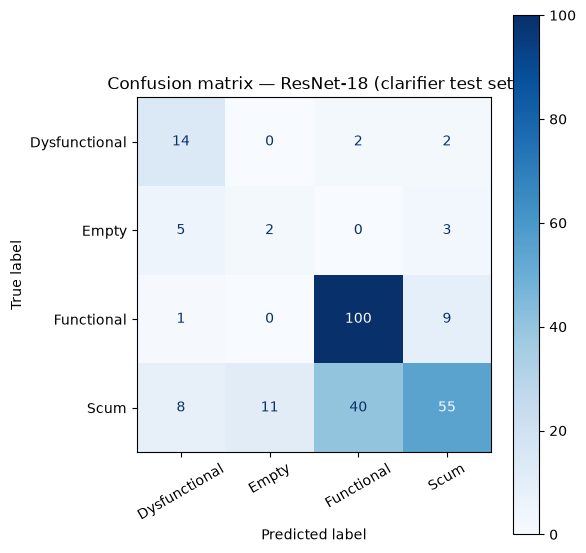

               precision    recall  f1-score   support

Dysfunctional      0.500     0.778     0.609        18
        Empty      0.154     0.200     0.174        10
   Functional      0.704     0.909     0.794       110
         Scum      0.797     0.482     0.601       114

     accuracy                          0.679       252
    macro avg      0.539     0.592     0.544       252
 weighted avg      0.710     0.679     0.669       252



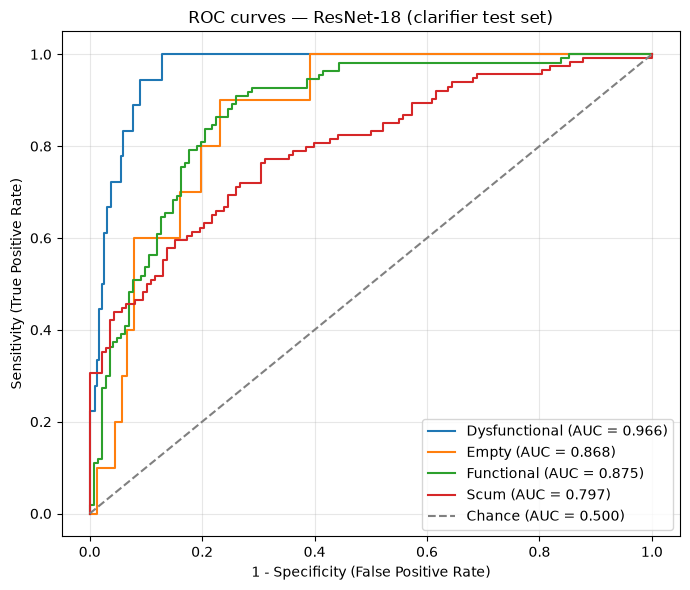

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.966
  Empty          : 0.868
  Functional     : 0.875
  Scum           : 0.797

Mean AUC (over 4/4 classes with test examples): 0.876


(np.float64(0.6785714285714286),
 {'Dysfunctional': 0.966286799620133,
  'Empty': 0.8677685950413223,
  'Functional': 0.8745198463508322,
  'Scum': 0.7970378845664887})

In [4]:
evaluate_and_record(
    model_resnet18, test_loader, "ResNet-18", history_resnet18,
    img_size=IMG_TARGET_SIZE, hidden_layers=0, neurons=None,
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [5]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/results_clarifier_resnet18_Fisantekraal.pkl


Saved model weights to ../models/clarifier_resnet18_cnn.pt
